<a href="https://colab.research.google.com/github/davidogm/RNAP/blob/main/BolsaRNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicción de valores bursátiles usando Redes Neuronales Recurrentes**

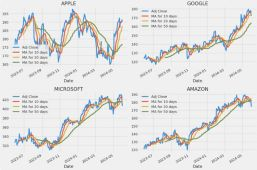


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import yfinance as yf

df = yf.download("AAPL", start='2018-1-1', end='2025-05-13', auto_adjust=True)



[*********************100%***********************]  1 of 1 completed


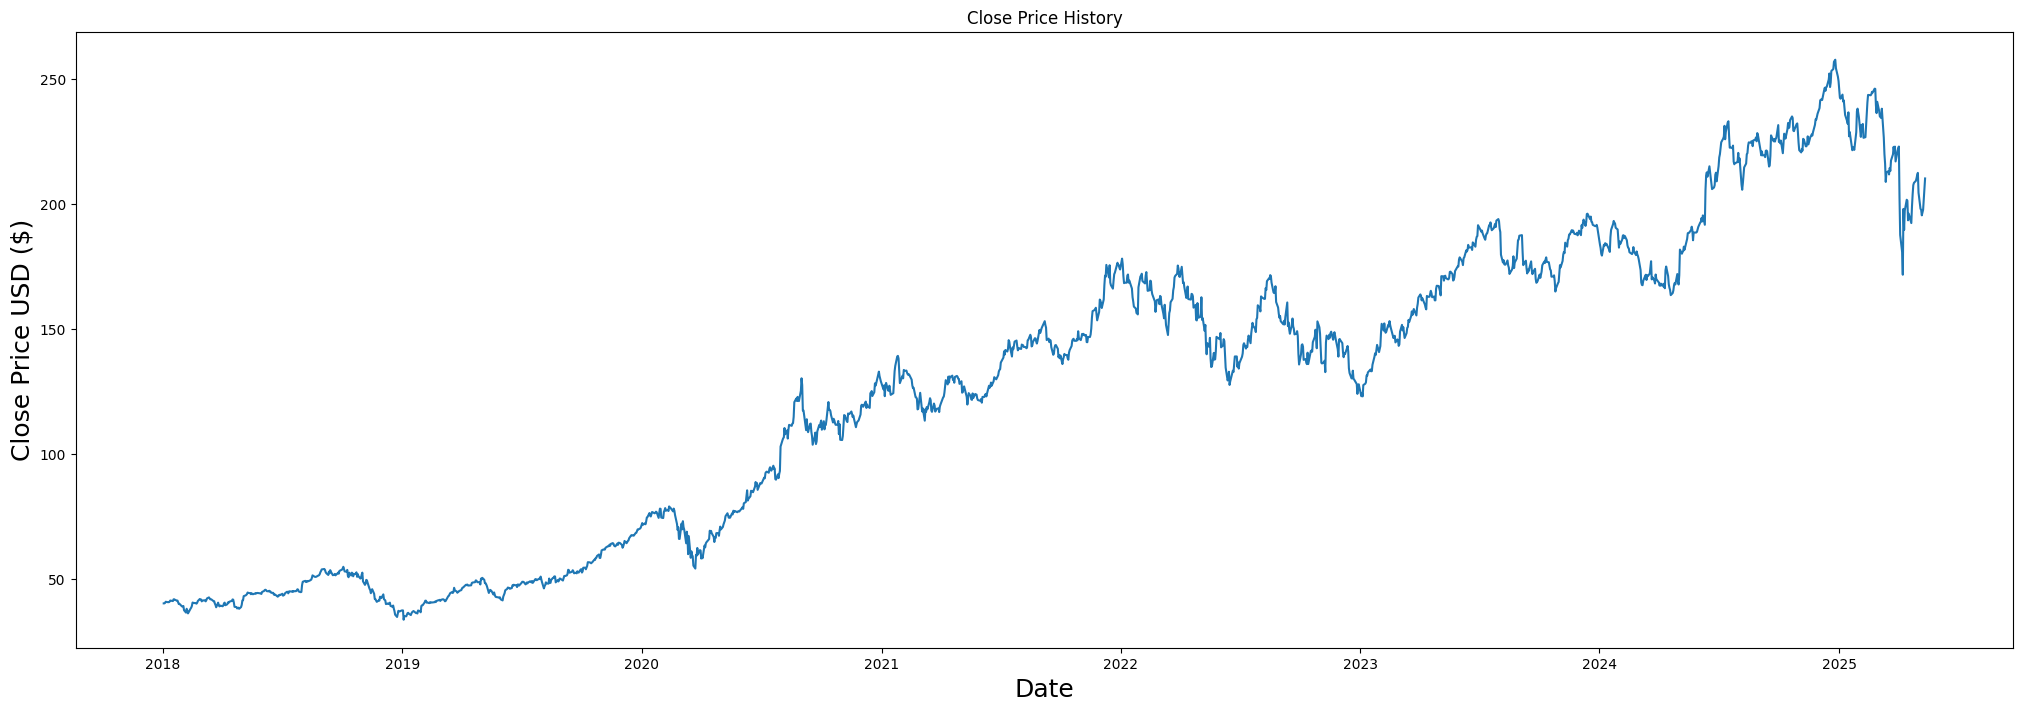

In [ ]:
# mostramos gráfica

plt.figure(figsize=(25,8))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [ ]:
# Create a new dataframe with only the 'Close column
# Nos quedamos sólo con Close por simplificar
data = df[['Close']]

In [ ]:

# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))
training_data_len

1758

In [ ]:
data.shape

(1850, 1)

In [ ]:
# Scale the data, lo preparamos para nuestra RNN
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.02919928],
       [0.02916791],
       [0.03000411],
       ...,
       [0.72758021],
       [0.73220608],
       [0.78796809]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.02919928, 0.02916791, 0.03000411, 0.03206324, 0.03138383,
       0.03136297, 0.03132116, 0.03235592, 0.03424786, 0.0333071 ,
       0.03634873, 0.03651599, 0.03567979, 0.03415372, 0.03419554,
       0.03124802, 0.02799726, 0.02841535, 0.02470473, 0.02366996,
       0.02415067, 0.02451657, 0.01690717, 0.01271573, 0.01955161,
       0.01590374, 0.01131511, 0.01329868, 0.01991057, 0.02162127,
       0.02480129, 0.03069955, 0.03011175, 0.0295031 , 0.0286845 ,
       0.03018526, 0.03333377, 0.03697557, 0.03636686, 0.03608345,
       0.03280902, 0.03407896, 0.03471918, 0.03456171, 0.03284052,
       0.03484508, 0.03803558, 0.03986172, 0.03802512, 0.03641936,
       0.03663973, 0.03597861, 0.03312387, 0.03306097, 0.02889437,
       0.02635461, 0.02225096, 0.03046869, 0.02581931, 0.02386722])]
[np.float64(0.025231594406539687)]

[array([0.02919928, 0.02916791, 0.03000411, 0.03206324, 0.03138383,
       0.03136297, 0.03132116, 0.03235592, 0.03424786, 0.0333071 ,
       0.03634873, 0.0

In [ ]:
# revisemos las dimensiones de los conjuntos de datos
print(data.shape)
print(train_data.shape)
print('el restante para el conjunto de test: %i' % (len(data)-len(train_data)))

(1850, 1)
(1758, 1)
el restante para el conjunto de test: 92


### Modelo RNN

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

# Build the RNN model
rnn_model = Sequential()
rnn_model.add(SimpleRNN(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
rnn_model.add(SimpleRNN(64, return_sequences=False))
rnn_model.add(Dense(25))
rnn_model.add(Dense(1))

# Compile the model
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
rnn_model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1698/1698 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - loss: 0.0090


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = rnn_model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step


np.float64(8.782884246098035)

In [ ]:
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
print (rmse)

8.782884246098035


In [ ]:
# vemos y comprobamos el tamaño dejado para el conjunto de datos test
test_data.shape

(152, 1)

In [ ]:
predictions

array([[248.57228],
       [247.7679 ],
       [244.78772],
       [242.2129 ],
       [237.91716],
       [234.64923],
       [234.89136],
       [235.69296],
       [233.46378],
       [231.43077],
       [227.01321],
       [223.46281],
       [224.79915],
       [222.70084],
       [220.71248],
       [218.63042],
       [216.97096],
       [214.75386],
       [215.99884],
       [218.3388 ],
       [227.14676],
       [230.1301 ],
       [231.85362],
       [227.37947],
       [223.36133],
       [222.15065],
       [223.01149],
       [226.29665],
       [224.1143 ],
       [223.53322],
       [223.65787],
       [226.60657],
       [227.47868],
       [234.30006],
       [233.9222 ],
       [236.57608],
       [236.8817 ],
       [237.51843],
       [237.85002],
       [240.22533],
       [237.51695],
       [233.75464],
       [234.31322],
       [232.07683],
       [227.43552],
       [226.30794],
       [226.34254],
       [227.47346],
       [224.18965],
       [214.93611],


/tmp/ipython-input-1052/3362873863.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions  # añadimos una columna al dataset test con las predicciones y así lo podemos comparar como vemos en la tabla de abajo


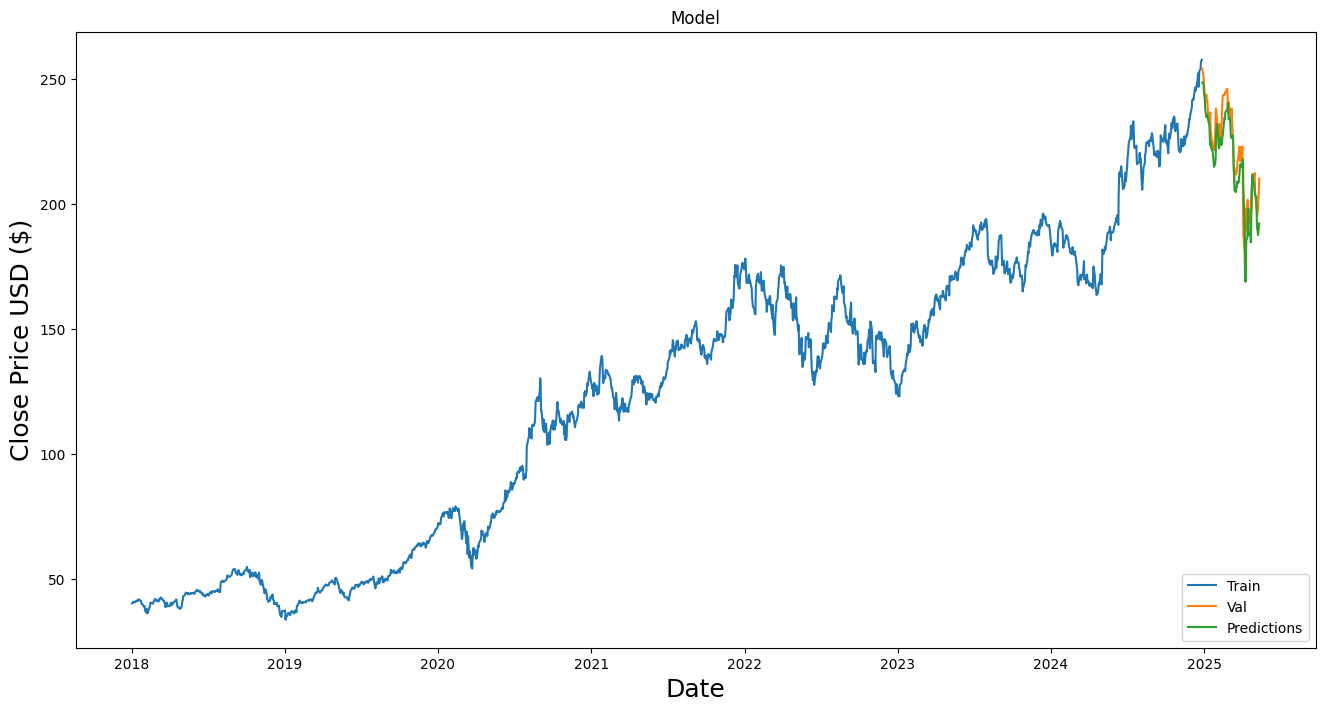

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions  # añadimos una columna al dataset test con las predicciones y así lo podemos comparar como vemos en la tabla de abajo
# Visualize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

# **Ejercicios**
### **Generar Predicciones RNN y GRU y Calcular RMSE**


1. Incluir otras tres acciones más además de AAPL
2. Generar predicciones a partir del modelo rnn_model y crear nuevos modelos para las redes LSTM y GRU utilizando el mismo conjunto de datos y luego calcular el RMSE para cada uno.
2. visualizar las predicciones de los tres modelos (LSTM, RNN y GRU) en comparación con los precios reales.

